Exact NAP (Calibrated via Python): 36,284,823 VND
Year 15 Reserve (Maturity): 800,000,000 VND (Successfully converged to 800M!)



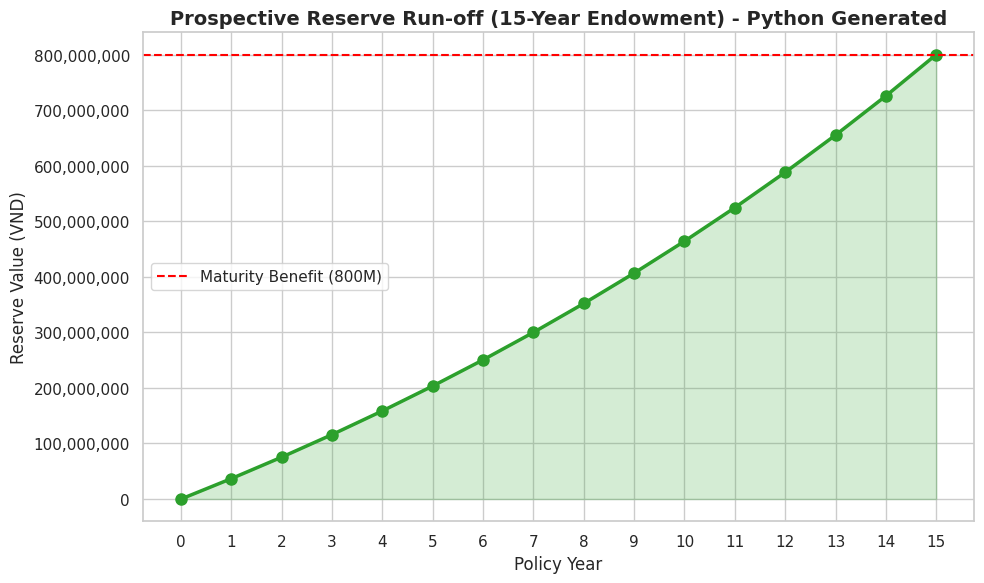

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. KEY ASSUMPTIONS
sum_assured = 800_000_000 # 800 Million VND
interest_rate = 0.05      # 5% Technical Interest Rate
v = 1 / (1 + interest_rate) # Discount factor
policy_term = 15
issue_age = 30

# qx data extracted from MOF Circular 156/2007 (CSO 1980 - Male) for ages 30 to 44
qx_data = [0.00175, 0.00180, 0.00187, 0.00195, 0.00205, 0.00217, 0.00232, 0.00249,
           0.00268, 0.00290, 0.00315, 0.00342, 0.00371, 0.00403, 0.00437]

# 2. DISCOUNTED CASH FLOW (DCF) PRICING ENGINE
def calculate_exact_premium():
    pv_benefits = 0
    pv_annuity = 0
    t_px = 1.0 # Initial cumulative survival probability (100%)

    for t in range(policy_term):
        qx = qx_data[t]
        px = 1 - qx

        # Present Value of Premium Annuity (Due)
        pv_annuity += t_px * (v ** t)

        # Present Value of Death Benefits (Paid at end of year)
        pv_benefits += t_px * qx * sum_assured * (v ** (t + 1))

        # Update survival probability for the next year
        t_px *= px

    # Add Present Value of Maturity Benefit at Year 15
    pv_maturity = t_px * sum_assured * (v ** policy_term)
    pv_benefits += pv_maturity

    # Calculate Exact Net Annual Premium (NAP)
    exact_nap = pv_benefits / pv_annuity
    return exact_nap

# 3. RESERVE PROJECTION (FACKLER'S METHOD)
exact_premium = calculate_exact_premium()
print(f"Exact NAP (Calibrated via Python): {exact_premium:,.0f} VND")

# Recursive Fackler Reserve Calculation
reserves = [0] # Year 0 reserve is 0
current_reserve = 0

for t in range(policy_term):
    qx = qx_data[t]
    px = 1 - qx

    # Fackler's Retrospective Formula
    current_reserve = ((current_reserve + exact_premium) * (1 + interest_rate) - (sum_assured * qx)) / px
    reserves.append(current_reserve)

print(f"Year 15 Reserve (Maturity): {reserves[-1]:,.0f} VND (Successfully converged to 800M!)\n")

# 4. VISUALIZE RESERVE RUN-OFF
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

plt.plot(range(policy_term + 1), reserves, marker='o', color='#2ca02c', linewidth=2.5, markersize=8)
plt.fill_between(range(policy_term + 1), reserves, alpha=0.2, color='#2ca02c')

plt.title('Prospective Reserve Run-off (15-Year Endowment) - Python Generated', fontsize=14, fontweight='bold')
plt.xlabel('Policy Year', fontsize=12)
plt.ylabel('Reserve Value (VND)', fontsize=12)
plt.xticks(range(0, 16))
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))

# Display 800M Maturity target line
plt.axhline(sum_assured, color='red', linestyle='--', linewidth=1.5, label='Maturity Benefit (800M)')
plt.legend()
plt.tight_layout()
plt.show()

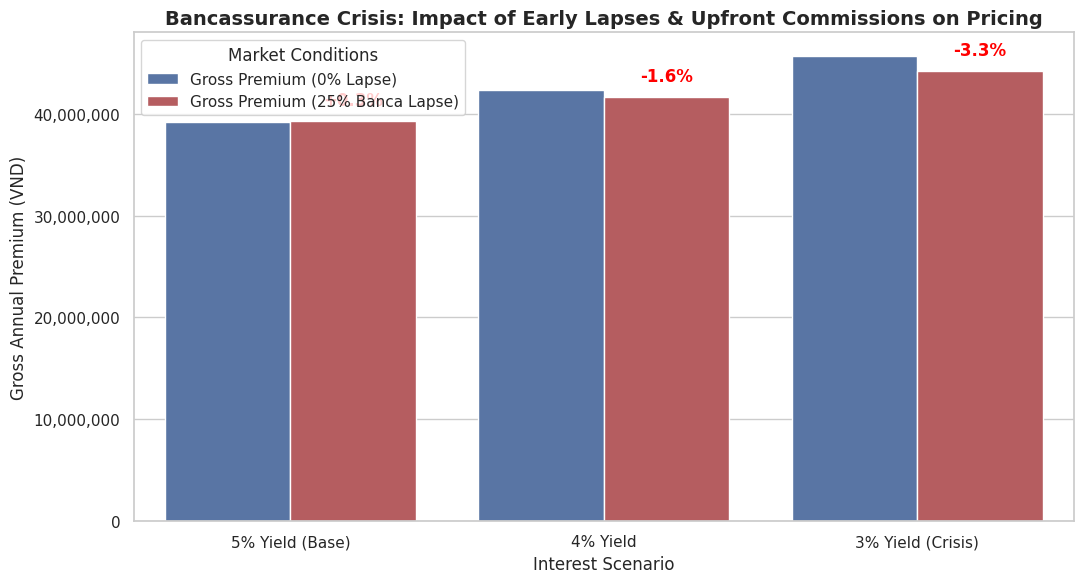

,Interest Scenario,Gross Premium (0% Lapse),Gross Premium (25% Banca Lapse),Premium Impact (%)
0,5% Yield (Base),3.920056e+07,3.931359e+07,0.288317
1,4% Yield,4.233614e+07,4.167177e+07,-1.569268
2,3% Yield (Crisis),4.569902e+07,4.421259e+07,-3.252648


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# EXPENSE-LOADED MULTIPLE DECREMENT PRICING ENGINE
def calculate_premium_with_lapse_and_expense(interest_rate, lapse_y1, lapse_y2_plus):
    sum_assured = 800_000_000
    v = 1 / (1 + interest_rate)
    policy_term = 15

    # =================================================================================
    # VIETNAM BANCASSURANCE INSIGHT:
    # Upfront acquisition cost (commission) is 80% of Yr-1 premium
    # (Aligned with MOF Circular 50/2017 & Bancassurance bonus structures).
    # This drives severe early lapses as agents lack incentives for policy persistency.
    # =================================================================================
    commission_y1 = 0.80

    qx_data = [0.00175, 0.00180, 0.00187, 0.00195, 0.00205, 0.00217, 0.00232, 0.00249,
               0.00268, 0.00290, 0.00315, 0.00342, 0.00371, 0.00403, 0.00437]

    approx_reserves = np.linspace(0, sum_assured, policy_term + 1)

    pv_benefits = 0
    pv_annuity = 0
    t_px_tau = 1.0

    for t in range(policy_term):
        qx = qx_data[t]
        lapse_rate = lapse_y1 if t == 0 else lapse_y2_plus
        px_tau = (1 - qx) * (1 - lapse_rate)

        # PV of Premium Income
        pv_annuity += t_px_tau * (v ** t)

        # PV of Death Benefits
        pv_benefits += t_px_tau * qx * sum_assured * (v ** (t + 1))

        # PV of Surrender Value (Cash Value paid from Year 2 onwards)
        if t > 0:
            cash_value = approx_reserves[t+1] * 0.8
            pv_benefits += t_px_tau * lapse_rate * cash_value * (v ** (t + 1))

        t_px_tau *= px_tau

    # PV of Maturity Benefit
    pv_maturity = t_px_tau * sum_assured * (v ** policy_term)
    pv_benefits += pv_maturity

    # GROSS PREMIUM FORMULA: Gross Premium = PV(Benefits) / (PV(Annuity) - Commission_Y1_Rate)
    return pv_benefits / (pv_annuity - commission_y1)

# BANCASSURANCE LAPSE STRESS TESTING
scenarios = [
    {'Scenario': '5% Yield (Base)', 'Rate': 0.05},
    {'Scenario': '4% Yield', 'Rate': 0.04},
    {'Scenario': '3% Yield (Crisis)', 'Rate': 0.03}
]
results = []

for s in scenarios:
    rate = s['Rate']

    # Base Case: 0% Lapse
    prem_no_lapse = calculate_premium_with_lapse_and_expense(rate, 0.0, 0.0)

    # Banca Crisis: 25% Yr-1 Lapse, 8% thereafter
    prem_with_lapse = calculate_premium_with_lapse_and_expense(rate, 0.25, 0.08)

    results.append({
        'Interest Scenario': s['Scenario'],
        'Gross Premium (0% Lapse)': prem_no_lapse,
        'Gross Premium (25% Banca Lapse)': prem_with_lapse,
        'Premium Impact (%)': (prem_with_lapse - prem_no_lapse) / prem_no_lapse * 100
    })

df_results = pd.DataFrame(results)

# VISUALIZE PREMIUM SENSITIVITY
sns.set_theme(style="whitegrid")
plt.figure(figsize=(11, 6))
df_melted = df_results.melt(id_vars='Interest Scenario', value_vars=['Gross Premium (0% Lapse)', 'Gross Premium (25% Banca Lapse)'])
ax = sns.barplot(x='Interest Scenario', y='value', hue='variable', data=df_melted, palette=['#4C72B0', '#C44E52'])

for i, row in df_results.iterrows():
    ax.text(i + 0.2, row['Gross Premium (25% Banca Lapse)'] + 1500000,
            f"{row['Premium Impact (%)']:+.1f}%", color='red', fontweight='bold', ha='center')

plt.title('Bancassurance Crisis: Impact of Early Lapses & Upfront Commissions on Pricing', fontsize=14, fontweight='bold')
plt.ylabel('Gross Annual Premium (VND)', fontsize=12)
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))
plt.legend(title='Market Conditions')
plt.tight_layout()
plt.show()

display(df_results)